### Dataset Name: House Price Prediction Dataset
https://drive.google.com/file/d/1aNw7f2sO16PlhqxdOeFBqwWDjjE1XrhT/view?usp=sharing
#
Business Scenario
A real estate analytics company helps customers estimate the market value of residential properties.
Property prices do not always increase smoothly:
- Prices jump based on location
- Amenities create sudden price differences
- Market behaviour is noisy and inconsistent
#
The company wants a reliable pricing system that can:
- Handle non-linear relationships
- Work well with noisy real-world data
#
Provide stable predictions for unseen properties
You are hired as a Data Analyst to build this pricing solution.
- Load the dataset and examine the available property attributes.
- Identify input features that may influence house prices (e.g., size, bedrooms, bathrooms, location-related fields).
- Build a regression model that predicts house price based on the selected features.
- Train the model using historical property data.Predict prices for unseen property records.
- Evaluate the model performance using:
    - Mean Squared Error (MSE)
    - R² score

    house_data.csv - Google Drive
 

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [64]:
df=pd.read_csv('house_data.csv')

In [65]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [66]:
df_encoded = pd.get_dummies(df, drop_first=True)

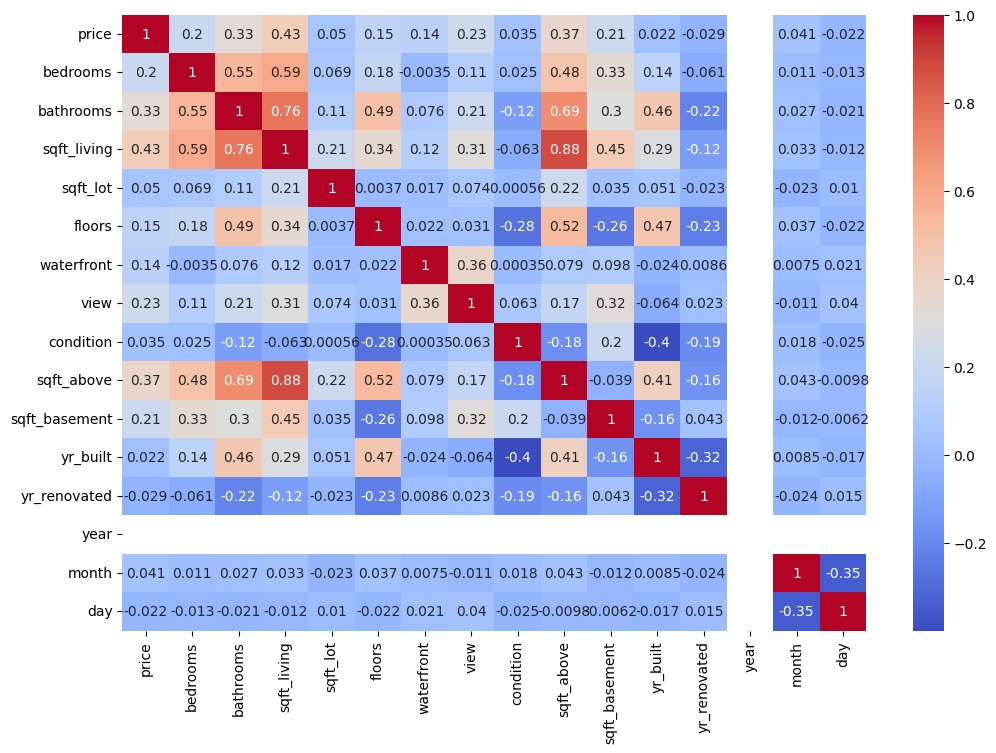

In [38]:

corr = df.select_dtypes(include='number').corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [67]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [73]:
X

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,...,False,False,False,False,False,False,False,False,False,False
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,...,False,False,False,False,False,False,False,False,False,False
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,...,False,False,False,False,False,False,False,False,False,False
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,...,False,False,False,False,False,False,False,False,False,False
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,...,False,False,False,False,False,False,False,False,False,False
4596,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,...,False,False,False,False,False,False,False,False,False,False
4597,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,...,False,False,False,False,False,False,False,False,False,False
4598,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,...,False,False,False,False,True,False,False,False,False,False


In [72]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree MSE:", dt_mse)
print("Decision Tree R²:", dt_r2)


Decision Tree MSE: 998562589939.1211
Decision Tree R²: 0.02086956565046738


In [68]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [69]:
y_pred_rf = rf.predict(X_test)

In [70]:
from sklearn.metrics import r2_score,mean_squared_error

In [71]:
print('r2_score = ',r2_score(y_test,y_pred_rf))
print('mean_squared_error = ',mean_squared_error(y_test,y_pred_rf))

r2_score =  0.04841222407381773
mean_squared_error =  970473310549.802


In [74]:
X=np.array([1,2,3,4,5,6]).reshape(-1,1)
y=np.array([35,40,50,60,65,70])

In [75]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)
y_train_pred=lin_reg.predict(X_train)
y_test_pred=lin_reg.predict(X_test)

In [77]:
print('good fit (linear regresssion )')
print('Train MSE = ',mean_squared_error(y_train,y_train_pred))
print('r2_score = ',r2_score(y_train,y_train_pred))

good fit (linear regresssion )
Train MSE =  1.875
r2_score =  0.9657142857142857


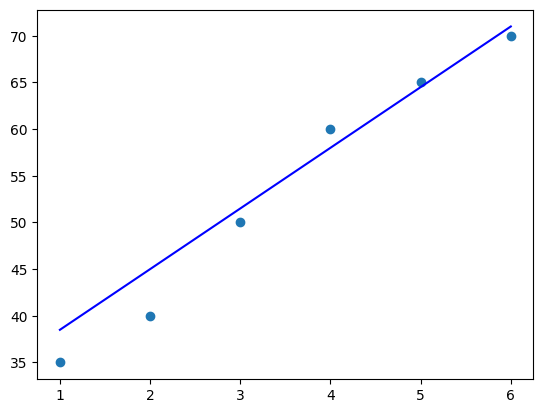

In [78]:
plt.scatter(X,y)
plt.plot(X,lin_reg.predict(X),color='blue')
plt.show()

In [88]:
ploy=PolynomialFeatures(degree=5)
X_train_ploy=ploy.fit_transform(X_train)
X_test_ploy=ploy.transform(X_test)

overfit_model=LinearRegression()
overfit_model.fit(X_train_ploy,y_train)

y_train_pred_ploy=overfit_model.predict(X_train_ploy)
y_test_pred_ploy=overfit_model.predict(X_test_ploy)

In [89]:
print('mean_squared_error = ',mean_squared_error(y_train,y_train_pred_ploy))
print('r2_score = ',r2_score(y_train,y_train_pred_ploy))

mean_squared_error =  8.23880018525583e-24
r2_score =  1.0


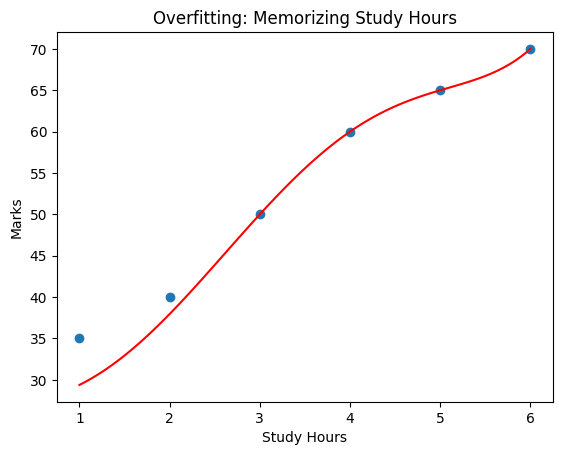

In [91]:
X_grid = np.linspace(1, 6, 100).reshape(-1, 1)
X_grid_poly = ploy.transform(X_grid)

plt.scatter(X, y)
plt.plot(X_grid, overfit_model.predict(X_grid_poly), color='red')
plt.title("Overfitting: Memorizing Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()


In [81]:
x_ploy=ploy.fit_transform(X)


In [84]:
from sklearn.linear_model import Ridge,Lasso
ridge=Ridge(alpha=1)
ridge.fit(x_ploy,y)
y_ridge_pred=ridge.predict(x_ploy)

In [83]:
print('mean_squared_error = ',mean_squared_error(y,y_ridge_pred))
print('r2_score = ',r2_score(y,y_ridge_pred))

mean_squared_error =  0.24058058055628095
r2_score =  0.9985320506949108


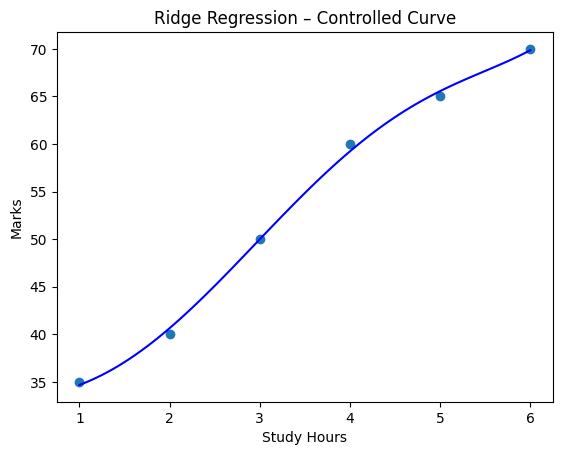

In [93]:
import matplotlib.pyplot as plt

X_grid = np.linspace(1, 6, 100).reshape(-1, 1)
X_grid_poly = ploy.transform(X_grid)

plt.scatter(X, y)
plt.plot(X_grid, ridge.predict(X_grid_poly), color='blue')
plt.title("Ridge Regression – Controlled Curve")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()


In [85]:
lasso=Lasso(alpha=0.1)
lasso.fit(x_ploy,y)
y_lasso_pred=lasso.predict(x_ploy)

C:\Users\reshmitha\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.580e+00, tolerance: 9.833e-02
  model = cd_fast.enet_coordinate_descent(


In [86]:
print('mean_squared_error = ',mean_squared_error(y,y_lasso_pred))
print('r2_score = ',r2_score(y,y_lasso_pred))

mean_squared_error =  0.7727384155729596
r2_score =  0.9952849859388768


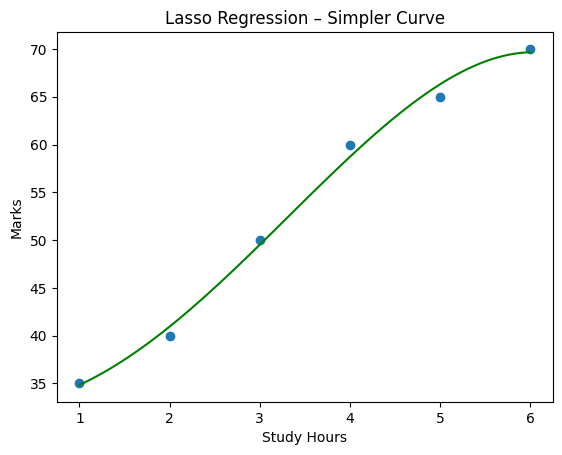

In [94]:
plt.scatter(X, y)
plt.plot(X_grid, lasso.predict(X_grid_poly), color='green')
plt.title("Lasso Regression – Simpler Curve")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()
